In [1]:
import os
os.makedirs('plots', exist_ok=True)
print("plots folder ready")

plots folder ready


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, roc_auc_score,
    f1_score, precision_score, recall_score,
    accuracy_score
)

data = pd.read_csv('Dataset/creditcard.csv')
data = data.drop_duplicates()

x_test = joblib.load('Preprocessed datasets/x_test.pkl')
y_test = joblib.load('Preprocessed datasets/y_test.pkl')

lr  = joblib.load('Saved Model/LogisticRegression.pkl')
rf  = joblib.load('Saved Model/RandomForest.pkl')
xgb = joblib.load('Saved Model/XGBoost.pkl')

models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb
}

plt.style.use('seaborn-v0_8-whitegrid')
print("All loaded successfully")
print(f"Dataset shape: {data.shape}")
print(f"Test set size: {len(y_test)}")

All loaded successfully
Dataset shape: (283726, 31)
Test set size: 56746


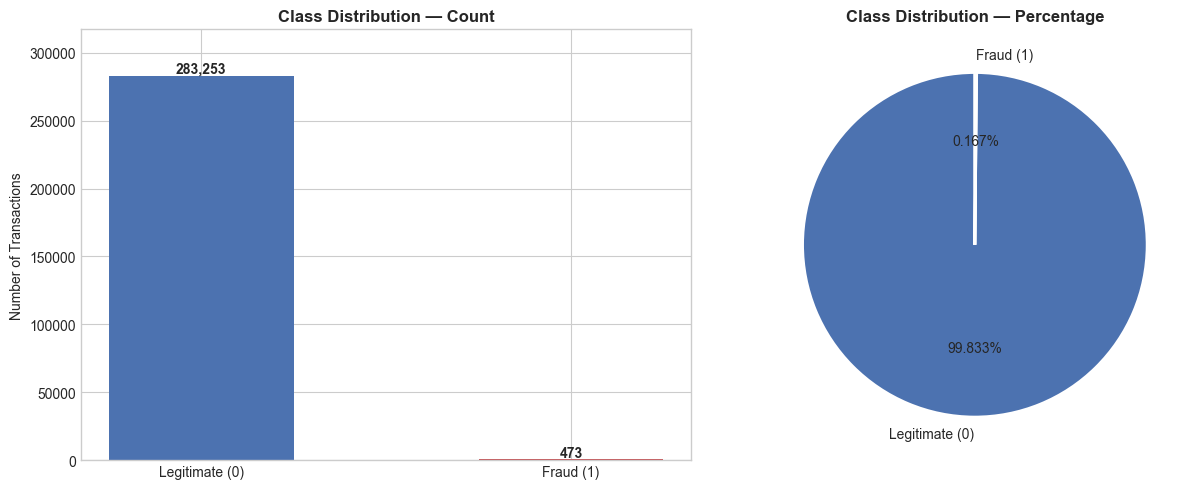

Saved: 01_class_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = data['Class'].value_counts()
labels = ['Legit (0)', 'Fraud (1)']
colors = ['#4C72B0', '#C44E52']

bars = axes[0].bar(labels, counts.values, color=colors, width=0.5)
axes[0].set_title('Class Distribution — Count', fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_ylim(0, counts.values[0] * 1.12)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2000,
                 f'{val:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, autopct='%1.3f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution — Percentage', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_class_distribution.png")

/var/folders/r7/jcjk903515sb1jh9whrg83bw0000gn/T/ipykernel_16119/2537666802.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([legit, fraud], labels=['Legit', 'Fraud'], patch_artist=True)


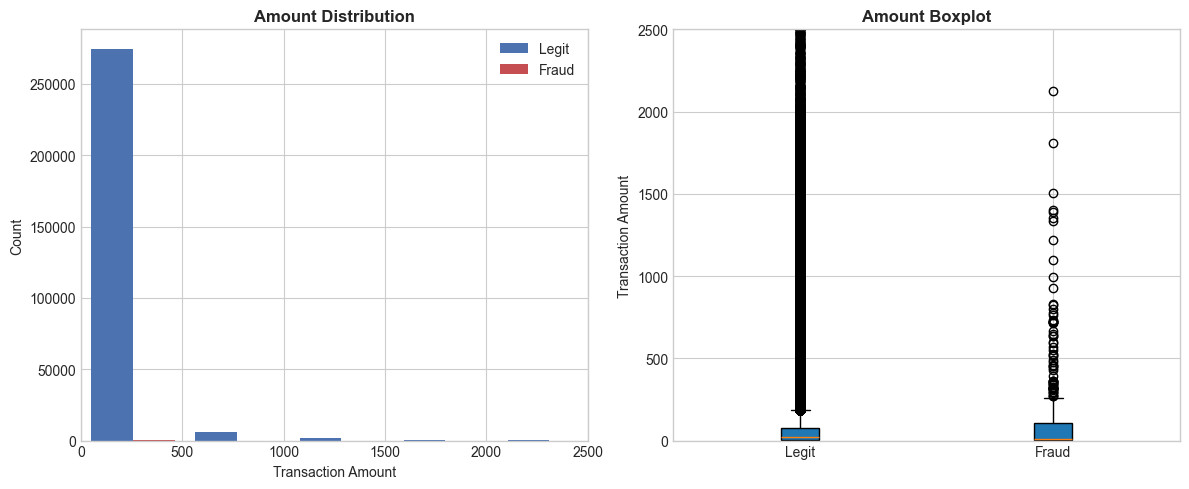

Saved: 02_amount_distribution.png


In [6]:
fraud = data[data['Class'] == 1]['Amount']
legit = data[data['Class'] == 0]['Amount']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist([legit, fraud], bins=50,
             color=['#4C72B0', '#C44E52'],
             label=['Legit', 'Fraud'])
axes[0].set_xlabel('Transaction Amount')
axes[0].set_ylabel('Count')
axes[0].set_title('Amount Distribution', fontweight='bold')
axes[0].set_xlim(0, 2500)
axes[0].legend()

axes[1].boxplot([legit, fraud], labels=['Legit', 'Fraud'], patch_artist=True)
axes[1].set_ylabel('Transaction Amount')
axes[1].set_title('Amount Boxplot', fontweight='bold')
axes[1].set_ylim(0, 2500)

plt.tight_layout()
plt.savefig('plots/02_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_amount_distribution.png")

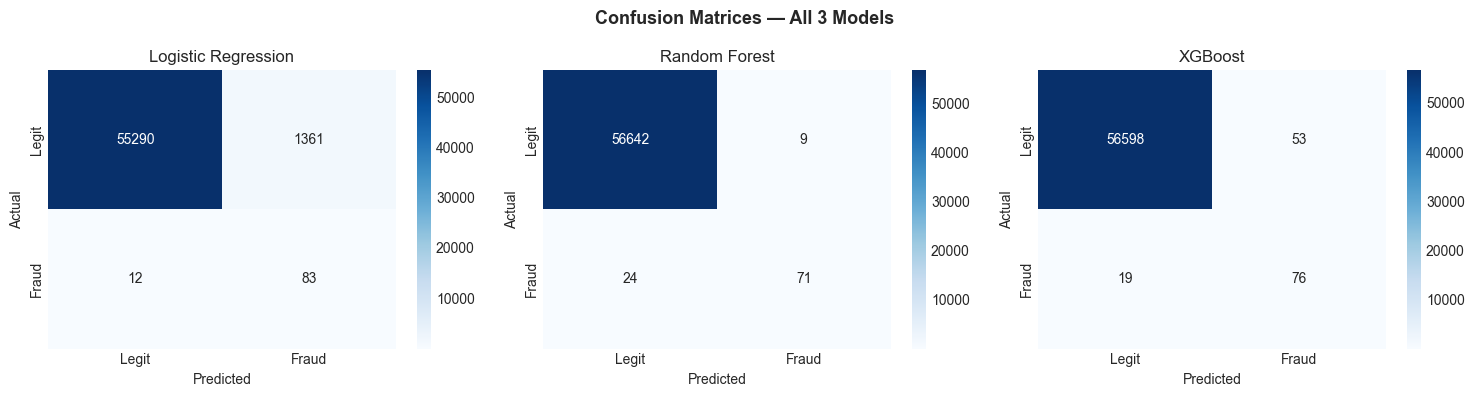

Saved: 03_confusion_matrices.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues',
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All 3 Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_confusion_matrices.png")

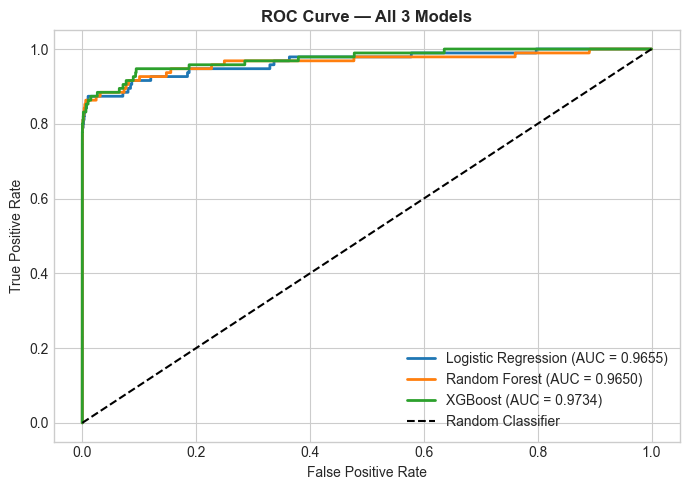

Saved: 04_roc_curves.png


In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, model in models.items():
    y_prob = model.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — All 3 Models', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('plots/04_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_roc_curves.png")

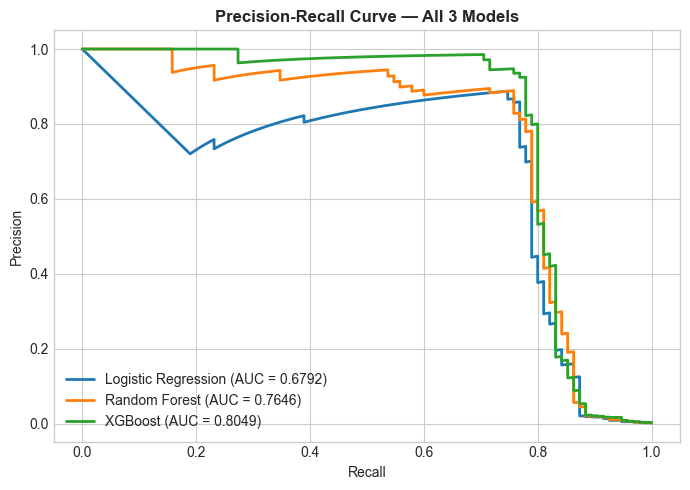

Saved: 05_precision_recall_curves.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, model in models.items():
    y_prob = model.predict_proba(x_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    ax.plot(recall, precision, lw=2, label=f'{name} (AUC = {pr_auc:.4f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — All 3 Models', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('plots/05_precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 05_precision_recall_curves.png")

           Logistic Regression  Random Forest  XGBoost
Accuracy                 97.58          99.94    99.87
Precision                 5.75          88.75    58.91
Recall                   87.37          74.74    80.00
F1 Score                 10.79          81.14    67.86
ROC AUC                  96.55          96.50    97.34


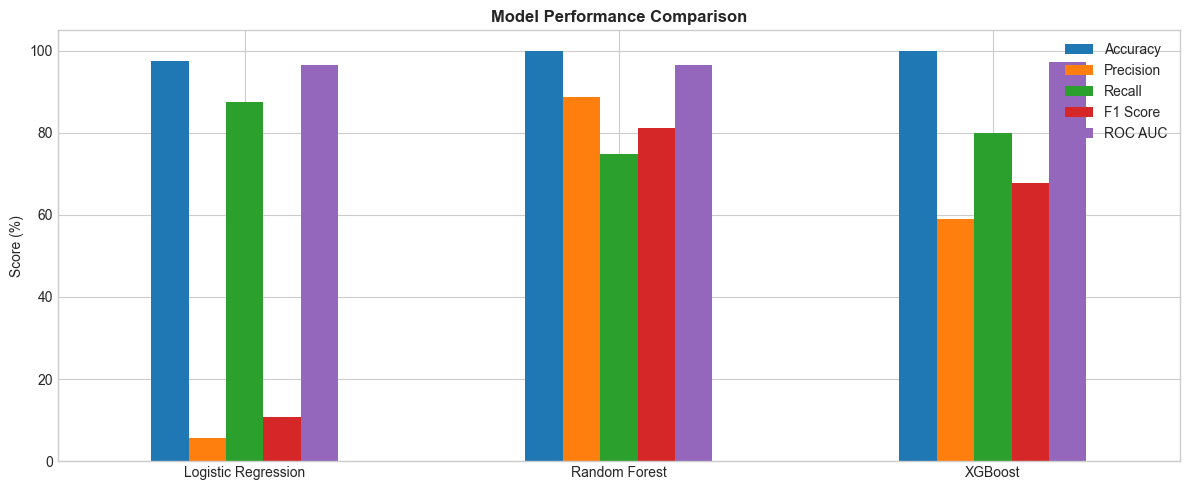

Saved: 06_model_comparison.png


In [10]:
results = {}
for name, model in models.items():
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]
    results[name] = [
        round(accuracy_score(y_test, y_pred) * 100, 2),
        round(precision_score(y_test, y_pred) * 100, 2),
        round(recall_score(y_test, y_pred) * 100, 2),
        round(f1_score(y_test, y_pred) * 100, 2),
        round(roc_auc_score(y_test, y_prob) * 100, 2)
    ]

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
df = pd.DataFrame(results, index=metrics)
print(df)

df.T.plot(kind='bar', figsize=(12, 5), rot=0)
plt.title('Model Performance Comparison', fontweight='bold')
plt.ylabel('Score (%)')
plt.legend()
plt.tight_layout()
plt.savefig('plots/06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06_model_comparison.png")

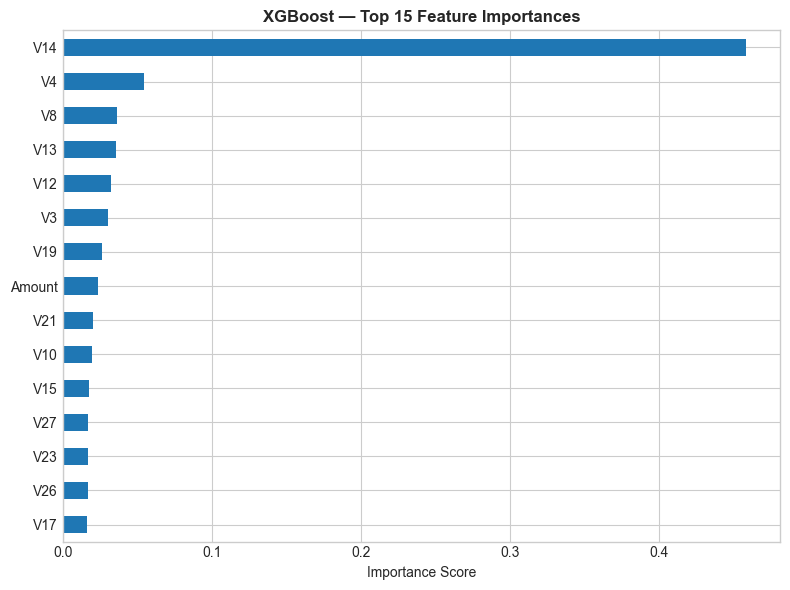

Saved: 07_feature_importance.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

importances = pd.Series(xgb.feature_importances_, index=x_test.columns)
importances.nlargest(15).sort_values().plot(kind='barh', ax=ax)

ax.set_title('XGBoost — Top 15 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('plots/07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 07_feature_importance.png")